# nnUNet Result Visualization

Dataset003(5cls) / Dataset004(1cls) 예측 결과를 GT image - GT mask - Pred mask 순으로 시각화.

In [11]:
import numpy as np
import pandas as pd
import nibabel as nib
import SimpleITK as sitk
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from pathlib import Path
from scipy import ndimage
import SimpleITK as sitk

NNUNET_ROOT = Path("/home/jovyan/aicon-gamma-datavol-1/hjgoh/ich-vlm/nnUNet")

## 1. class

In [ ]:
class_map = {
    0: 'background',
    1: 'epidural',
    2: 'intraparenchymal',
    3: 'intraventricular',
    4: 'subarachnoid',
    5: 'subdural',
}

class_names = {
    1: 'EDH',
    2: 'IPH',
    3: 'IVH',
    4: 'SAH',
    5: 'SDH',
}

class_colors = {
    1: (198, 68, 66),    # EDH
    2: (76, 71, 199),    # IPH
    3: (171, 43, 171),   # IVH
    4: (168, 181, 112),  # SAH
    5: (4, 136, 133),    # SDH
}

class_names_1cls = {
    0: 'background',
    1: 'ich',
}

class_colors_1cls = {
    0: (0, 0, 0),
    1: (0, 255, 255),
}

In [ ]:
def build_cmap(color_dict, n_classes):
    colors_rgb = np.zeros((n_classes, 3))
    for cls, rgb in color_dict.items():
        colors_rgb[cls] = np.array(rgb) / 255.0
    return ListedColormap(colors_rgb)

cmap_5cls = build_cmap(class_colors, 6)   # 0(background, black)~5
cmap_1cls = build_cmap(class_colors_1cls, 2)

def apply_window(slice_hu, window_level=40, window_width=80):
    lo, hi = window_level - window_width / 2, window_level + window_width / 2
    return (np.clip(slice_hu, lo, hi) - lo) / (hi - lo)

## 2. 설정 — 3개

In [23]:
DATASET = "004"        # "003"(5cls) or "004"(1cls)
TEST_SET = "CT-ICH"  # "MBH-Seg25" or "CT-ICH"
CONFIG = "3d_fullres"    # "3d_fullres" or "2d"

IS_5CLS = (DATASET == "003")
N_CLASSES = 6 if IS_5CLS else 2
CMAP = cmap_5cls if IS_5CLS else cmap_1cls
CLS_NAMES = class_names if IS_5CLS else class_names_1cls
FG_CLASSES = list(class_names.keys()) if IS_5CLS else [1]

pred_root = NNUNET_ROOT / "nnUNet_predictions" / f"Dataset{DATASET}_MBHSeg25{'_1cls' if not IS_5CLS else ''}" / CONFIG / TEST_SET

if IS_5CLS:
    test_dir_name = "Test1_MBHSeg25" if TEST_SET == "MBH-Seg25" else "Test2_CTICH"
    gt_dir = NNUNET_ROOT / "nnUNet_test" / test_dir_name
else:
    test_dir_name = "Test1_MBHSeg25_1cls" if TEST_SET == "MBH-Seg25" else "Test2_CTICH_1cls"
    gt_dir = NNUNET_ROOT / "nnUNet_test_1cls" / test_dir_name

images_dir = gt_dir / "imagesTs"
labels_dir = gt_dir / "labelsTs"

print(f"설정: Dataset{DATASET} / {TEST_SET} / {CONFIG}")
print(f"GT: {gt_dir}")
print(f"예측: {pred_root}")

설정: Dataset004 / CT-ICH / 3d_fullres
GT: /home/jovyan/aicon-gamma-datavol-1/hjgoh/ich-vlm/nnUNet/nnUNet_test_1cls/Test2_CTICH_1cls
예측: /home/jovyan/aicon-gamma-datavol-1/hjgoh/ich-vlm/nnUNet/nnUNet_predictions/Dataset004_MBHSeg25_1cls/3d_fullres/CT-ICH


## 3. 케이스 매칭

In [24]:
gt_cases = sorted(p.stem.replace('.nii', '') for p in labels_dir.glob("*.nii.gz"))
pred_cases = sorted(p.stem.replace('.nii', '') for p in pred_root.glob("*.nii.gz")) if pred_root.exists() else []

case_ids = [c for c in gt_cases if c in set(pred_cases)]
missing = [c for c in gt_cases if c not in set(pred_cases)]

print(f"GT 케이스: {len(gt_cases)}개")
print(f"예측 있는 케이스: {len(case_ids)}개")
if missing:
    print(f"예측 없어서 제외된 케이스: {len(missing)}개 (예: {missing[:5]})")

if len(case_ids) == 0:
    print("!! 매칭되는 케이스가 없습니다. DATASET/TEST_SET/CONFIG 조합을 확인하세요.")


GT 케이스: 75개
예측 있는 케이스: 75개


## 4. Dice/IoU 계산

In [ ]:
def dice_iou(pred, gt, cls):
    p = pred == cls
    g = gt == cls
    inter = np.logical_and(p, g).sum()
    union = np.logical_or(p, g).sum()
    p_sum, g_sum = p.sum(), g.sum()
    if p_sum + g_sum == 0:
        return np.nan, np.nan
    dice = 2 * inter / (p_sum + g_sum)
    iou = inter / union if union > 0 else np.nan
    return dice, iou

def compute_case_metrics(case_id):
    gt = np.asarray(nib.load(str(labels_dir / f"{case_id}.nii.gz")).dataobj).astype(np.uint8)
    pred = np.asarray(nib.load(str(pred_root / f"{case_id}.nii.gz")).dataobj).astype(np.uint8)

    per_class = {}
    for c in FG_CLASSES:
        d, i = dice_iou(pred, gt, c)
        per_class[c] = (d, i)

    dices = [v[0] for v in per_class.values() if not np.isnan(v[0])]
    ious = [v[1] for v in per_class.values() if not np.isnan(v[1])]
    mean_dice = np.mean(dices) if dices else np.nan
    mean_iou = np.mean(ious) if ious else np.nan
    return mean_dice, mean_iou, per_class

## 5. 전체 케이스 숫자 표

In [26]:
rows = []
for case_id in case_ids:
    mean_dice, mean_iou, per_class = compute_case_metrics(case_id)
    row = {"case": case_id, "Dice": mean_dice, "IoU": mean_iou}
    if IS_5CLS:
        for c, name in class_names.items():
            row[f"{name}_dice"] = per_class[c][0]
    rows.append(row)

df_metrics = pd.DataFrame(rows)
display(df_metrics.round(4))
print("\n평균:")
print(df_metrics.drop(columns="case").mean(numeric_only=True).round(4))


,case,Dice,IoU
0,ctich_049,0.7129,0.5539
1,ctich_050,0.5505,0.3798
2,ctich_051,0.6789,0.5139
3,ctich_052,0.7946,0.6592
4,ctich_053,0.6920,0.5291
...,...,...,...
70,ctich_126,NaN,NaN
71,ctich_127,NaN,NaN
72,ctich_128,0.0000,0.0000
73,ctich_129,0.0000,0.0000



평균:
Dice    0.4113
IoU     0.3242
dtype: float64


## 6. 시각화

`show_case(idx)` — GT 기준 병변 최대 z 자동 선택
`show_case(idx, z=15)` — z 직접 지정

In [10]:
def load_lps_array(path):
    """DICOM 표준 axial view(anterior=위, 방사선과 관례 좌우)로 보이도록 LPS 재정렬 후 (z, y, x) 배열 반환."""
    img_sitk = sitk.ReadImage(str(path))
    img_lps = sitk.DICOMOrient(img_sitk, "LPS")
    return sitk.GetArrayFromImage(img_lps)  # (z, y, x)


def show_case(idx, z=None):
    case_id = case_ids[idx]
    img = load_lps_array(images_dir / f"{case_id}_0000.nii.gz")
    gt = load_lps_array(labels_dir / f"{case_id}.nii.gz").astype(np.uint8)
    pred = load_lps_array(pred_root / f"{case_id}.nii.gz").astype(np.uint8)

    if z is None:
        fg_per_slice = (gt > 0).sum(axis=(1, 2))
        z = int(fg_per_slice.argmax())

    mean_dice, mean_iou, per_class = compute_case_metrics(case_id)

    windowed = apply_window(img[z])
    gt_slice = gt[z]
    pred_slice = pred[z]
    gt_overlay = np.ma.masked_where(gt_slice == 0, gt_slice)
    pred_overlay = np.ma.masked_where(pred_slice == 0, pred_slice)

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    axes[0].imshow(windowed, cmap='gray', vmin=0, vmax=1)
    axes[0].set_title(f"{case_id} (z={z}/{img.shape[0]-1})")
    axes[0].axis('off')

    axes[1].imshow(windowed, cmap='gray', vmin=0, vmax=1)
    axes[1].imshow(gt_overlay, cmap=CMAP, vmin=0, vmax=N_CLASSES - 1, alpha=0.6)
    axes[1].set_title("GT mask")
    axes[1].axis('off')

    axes[2].imshow(windowed, cmap='gray', vmin=0, vmax=1)
    axes[2].imshow(pred_overlay, cmap=CMAP, vmin=0, vmax=N_CLASSES - 1, alpha=0.6)
    axes[2].set_title("Predicted mask")
    axes[2].axis('off')
    axes[2].text(
        0.98, 0.02, f"mDice: {mean_dice:.3f}\nmIoU: {mean_iou:.3f}",
        transform=axes[2].transAxes, ha='right', va='bottom',
        color='white', fontsize=12, fontweight='bold',
        bbox=dict(facecolor='black', alpha=0.6, edgecolor='none', pad=4),
    )

    plt.tight_layout()
    plt.show()

    print(f"case: {case_id} | z: {z}")
    print(f"mDice: {mean_dice:.4f} | mIoU: {mean_iou:.4f}")
    if IS_5CLS:
        for c, name in class_names.items():
            d, i = per_class[c]
            print(f"  {name}: Dice={d:.4f}, IoU={i:.4f}" if not np.isnan(d) else f"  {name}: (해당 없음)")


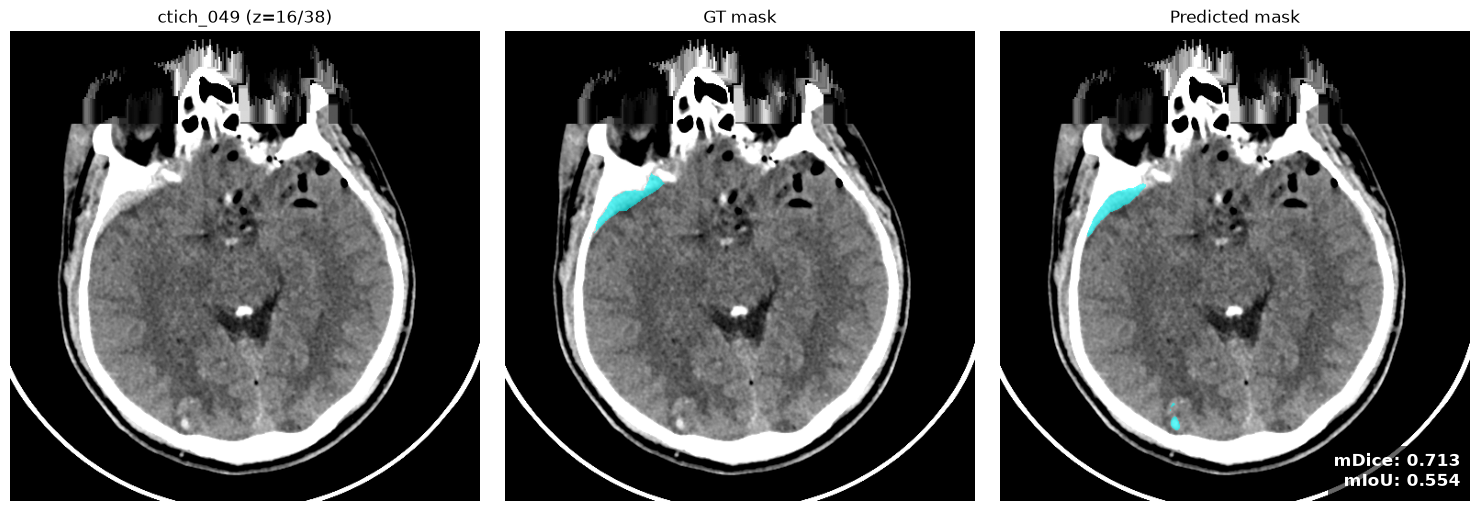

case: ctich_049 | z: 16
mDice: 0.7129 | mIoU: 0.5539


In [ ]:
# 사용 예: show_case(0)  또는  show_case(3, z=15)
show_case(0, z=1)